In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
import scipy
import matplotlib as mpl
from scipy.special import gamma

STARTING_RANGE_PARAMETER = 0.001 # In [fm^-2]
ENDING_RANGE_PARAMETER = 250
REDUCED_MASS = 935 * (4 / 5) # In [Mev / c^2], need to update value and units (10/11 A in MeV)
SUM_LIMIT = 50 # Determines the number of gaussians we expand our wave function to

V_LS = 11.71 # In MeV
DIFFUSIVITY = 0.6 # Diffusivity, may want to check the vaidity of this paticular number
r_0 = 1.2 # In fm, may want to chose a better value for small nuclei
A_C = 4 # The number of nucleons in the core

NUM_SUSY_GAUSSIANS = 15
SUSY_POTENTIAL_PARAMS = [0.015625,0.0192901,0.023815,0.0294012,0.0362978,0.0448121,0.0553235,0.0683007,0.0843218,0.104101,0.12852,0.158666,0.195884,0.241833,0.298559]
SUSY_POTENTIAL_COEFFS = [-912.425,2142.06,-409.428,-2018.96,47.0009,2144.66,335.787,-2156.45,-288.529,2091.06,-355.062,-1696.92,1654.04,-660.762,103.905]
CENTRAL_POTENTIAL_STRENGTH = -47.32 * 2

CENTRAL_POTENTIAL_PARAMETERS = [1 / ((2.30)**2)]

CENTRAL_MIXING_COEFFICIENTS = [1]

SPIN_ORBIT_POTENTIAL_PARAMETERS = [1 / (2.30**2)]

SPIN_ORBIT_MIXING_COEFFICIENTS = [1]

In [3]:
def single_particle_overlap(range_parameter_i, range_parameter_j):
    return ((2 * range_parameter_i * range_parameter_j) / (range_parameter_i**2 + range_parameter_j**2))**(1.5)

def single_particle_potential_element(range_parameter_i, range_parameter_j, central_potential_mixing_coefficient,
                             central_potential_param):
    V_0 = -47.32 * 2
    term_1 = 2 / (range_parameter_i * range_parameter_j)
    term_2 = 1 / ((1 / range_parameter_i**2) + (1 / range_parameter_j**2) + central_potential_param)
    return V_0 * (term_1 * term_2)**(1.5)

def single_particle_kinetic_element(range_parameter_i, range_parameter_j, μ=REDUCED_MASS):
    term_1 = range_parameter_i**2 + range_parameter_j**2
    return (197**2 / (2 * μ)) * 6 * single_particle_overlap(range_parameter_i, range_parameter_j) / term_1

def super_symmetric_potential_element(range_param_i, range_param_j, central_potential_mixing_coefficient,
                                      central_potential_param, k_value, μ=REDUCED_MASS):
    """
    Supersymmetric potential that removes the bound 1s groundstate
    associated with the neutrons in the He-4 core.
    """
    core_neutron_potential =  potential_matrix_element(range_param_i, range_param_j, central_potential_mixing_coefficient,
                                                       central_potential_param)
    alpha_k = 1 / next_range_parameter(k_value)**0.5
    super_symmetry_term = 2 * (197**2 / μ) * alpha_k**(-2) *  overlap_matrix_element(range_param_i, range_param_j)
    return core_neutron_potential + super_symmetry_term

In [4]:
def matrix_generation(central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                      spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                      spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS, size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size))
    n_matrix = np.zeros(shape=(size, size))

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = single_particle_kinetic_element(i_range_parameter, j_range_parameter)
            potential_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += single_particle_potential_element(i_range_parameter,
                                                                  j_range_parameter, central_mixing_coefficients[k],
                                                                  central_potential_parameters[k])
            h_matrix[i, j] = kinetic_energy_term + potential_energy_term
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = single_particle_overlap(i_range_parameter, j_range_parameter)

    return h_matrix, n_matrix


def susy_correction_mat_gen(tot_ang_momentum, orb_ang_momentum, k_value, theta, central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                      spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                      spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS, size=SUM_LIMIT):
    h_matrix = np.zeros(shape=(size, size), dtype=np.complex_)
    n_matrix = np.zeros(shape=(size, size), dtype=np.complex_)

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = single_particle_kinetic_element(i_range_parameter, j_range_parameter)
            potential_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += single_particle_potential_element(i_range_parameter,
                                                                  j_range_parameter, central_mixing_coefficients[k],
                                                                  central_potential_parameters[k])
            h_matrix[i, j] = kinetic_energy_term + potential_energy_term
            # h_matrix[j, i] = h_matrix[i, j]
            n_matrix[i, j] = single_particle_overlap(i_range_parameter, j_range_parameter)
            # ((2 * 10**(np.abs(i - j))) / (1 + 10**(2 * np.abs(i - j))))**(1.5 + orb_ang_momentum)
            # n_matrix[j, i] = n_matrix[i, j]
            # j += 1

    return h_matrix, n_matrix


def next_range_parameter(i, starting_range_parameter=STARTING_RANGE_PARAMETER, ending_range_parameter=ENDING_RANGE_PARAMETER,
                         sum_limit=SUM_LIMIT):
    """
    Finds the next range parameter given the previous and initial range parameters.
    Currently using a simple geometric series to determine range parameters.
    Chose geometric basis parameters $\alpha_i = \alpha_1a^{i-1}$ with initial parameters $\alpha_1 = 0.01, a=2$

    Parameters
    ----------
    i : int detailing the iteration number

    Returns
    -------
    new_range_parameter: float

    """
    geometric_progression_number = (ending_range_parameter / starting_range_parameter)**(1 / (sum_limit - 1))
    new_range_parameter = starting_range_parameter * geometric_progression_number**(i)
    #new_range_parameter = 1 / new_range_parameter**2

    return new_range_parameter

#theta = 5 * np.pi / 36 
#s_h_matrix, s_n_matrix = matrix_generation(0.5, 0, theta)
#p_one_half_h_matrix, p_one_half_n_matrix = matrix_generation(0.5, 1, theta)
#p_three_half_h_matrix, p_three_half_n_matrix = matrix_generation(1.5, 1, theta)
#d_five_half_h_matrix, d_five_half_n_matrix = matrix_generation(2.5, 2, theta)

In [5]:
s_h_matrix, s_n_matrix = matrix_generation()
s_eigenvalues, s_eigenvectors = scipy.linalg.eigh(s_h_matrix, s_n_matrix)
s_overlap_eigenvalues, s_overlap_eigenvectors = scipy.linalg.eigh(s_n_matrix)
s_overlap_matrix_condition_number = np.max(s_overlap_eigenvalues) / np.min(s_overlap_eigenvalues)
print(f"The s 1/2 overlap matrix condition number is", s_overlap_matrix_condition_number)

s0_eigenvector = np.asmatrix(s_eigenvectors[:, 0])
s1_eigenvector = np.asmatrix(s_eigenvectors[:, 1])
print("The S state eigenvalues are", s_eigenvalues)
print("The S0 eigenvector is", s0_eigenvector)
#print(s_eigenvalues[0])

The s 1/2 overlap matrix condition number is 12036649.786045901
The S state eigenvalues are [-3.97191215e+01 -2.92477499e-01  7.43070997e-04  3.15885795e-03
  7.87356389e-03  1.61647275e-02  3.03707704e-02  5.46252525e-02
  9.61605907e-02  1.67590867e-01  2.90880361e-01  5.04218913e-01
  8.74285608e-01  1.51849032e+00  2.64671774e+00  4.63870857e+00
  8.18933074e+00  1.45543742e+01  2.59537474e+01  4.62023723e+01
  8.17032233e+01  1.43709937e+02  2.52146106e+02  4.40244218e+02
  7.61681078e+02  1.30394751e+03  2.21148727e+03  3.72402156e+03
  6.23987069e+03  1.04208877e+04  1.73666137e+04  2.89034779e+04
  4.80651296e+04  7.98902839e+04  1.32748079e+05  2.20540034e+05
  3.66359295e+05  6.08574283e+05  1.01095059e+06  1.67951370e+06
  2.79070503e+06  4.63857876e+06  7.71445125e+06  1.28428916e+07
  2.14186139e+07  3.58336371e+07  6.02947419e+07  1.02558077e+08
  1.78359800e+08  3.27871498e+08]
The S0 eigenvector is [[ 1.31992640e-11 -7.59278228e-11  2.42055976e-10 -5.83304917e-10
   1.2

Ground state wavefunction has overlap 1.0000000000000018 with itself


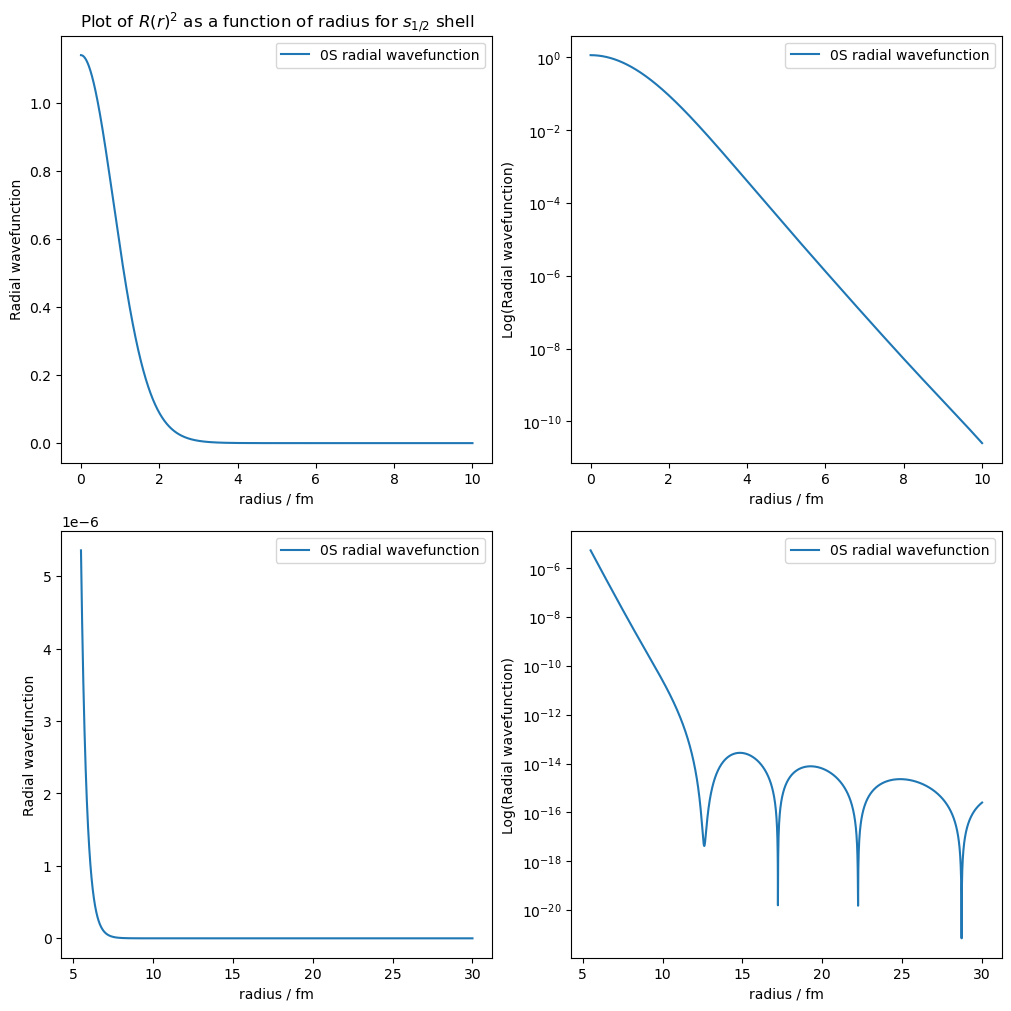

In [6]:
def wavefunction_overlap(orb_ang_momentum_i, orb_ang_momentum_j, i_mixing_coefficients, j_mixing_coefficients, overlap_matrix=None, size=SUM_LIMIT):
    try:
        _ = overlap_matrix.shape
        return (i_mixing_coefficients * overlap_matrix * np.transpose(j_mixing_coefficients))[0, 0]
    except AttributeError:
        overlap_matrix = np.zeros(shape=(size, size))

        for i in range(size):
            i_range_parameter = next_range_parameter(i)
            for j in range(size):
                j_range_parameter = next_range_parameter(j)
                overlap_matrix[i, j] = different_l_overlap_matrix_element(orb_ang_momentum_i, orb_ang_momentum_j, i_range_parameter, j_range_parameter)

        return (i_mixing_coefficients * overlap_matrix * np.transpose(j_mixing_coefficients))[0, 0]
print(f'Ground state wavefunction has overlap {wavefunction_overlap(0, 0, s0_eigenvector, s0_eigenvector, overlap_matrix=s_n_matrix)} with itself')

def radial_wavefunction(x_values, wavefunction_eigenvector, orbital_quantum_number, sum_limit=SUM_LIMIT):
    """
    Defines a numerical method of finding the reduced radial wavefunction as a sum of our gaussians.
    """
    def gaussian_wavefunction(radius, range_parameter, orb_ang_momentum):
        normalisation = (2**(-2.5 - orb_ang_momentum) * (range_parameter)**(3 + 2 * orb_ang_momentum) * gamma(1.5 + orb_ang_momentum))**(-0.5)
        return normalisation * radius**(orb_ang_momentum) * np.exp(- (radius / range_parameter)**2)
    wavefunction_vals = np.zeros(shape=(len(x_values),))

    for i in range(len(x_values)):
        for j in range(sum_limit):
            range_parameter = next_range_parameter(j)
            wavefunction_vals[i] += (wavefunction_eigenvector[0, j] * gaussian_wavefunction(x_values[i], 
                range_parameter, orbital_quantum_number))
        wavefunction_vals[i] = wavefunction_vals[i]**2
    return wavefunction_vals

x_values = np.linspace(0, 10, 3000)
x_values_2 = np.linspace(5.5, 30, 3000)

fig = plt.figure(figsize=(10, 10), layout='constrained')
spec = fig.add_gridspec(ncols=2, nrows=2)
ax_1 = fig.add_subplot(spec[0,0])
ax_2 = fig.add_subplot(spec[0,1])
ax_3 = fig.add_subplot(spec[1,0])
ax_4 = fig.add_subplot(spec[1,1])
ax_1.set_title(r'Plot of $R(r)^{2}$ as a function of radius for $s_{1/2}$ shell')
ax_1.set_xlabel('radius / fm')
ax_1.set_ylabel('Radial wavefunction')
ax_1.plot(x_values, radial_wavefunction(x_values, s0_eigenvector, 0), label="0S radial wavefunction")
ax_1.legend()

ax_2.set_xlabel('radius / fm')
ax_2.set_ylabel('Log(Radial wavefunction)')
ax_2.semilogy(x_values, radial_wavefunction(x_values, s0_eigenvector, 0), label="0S radial wavefunction")
ax_2.legend()

ax_3.set_xlabel('radius / fm')
ax_3.set_ylabel('Radial wavefunction')
ax_3.plot(x_values_2, radial_wavefunction(x_values_2, s0_eigenvector, 0), label="0S radial wavefunction")
ax_3.legend()

ax_4.set_xlabel('radius / fm')
ax_4.set_ylabel('Log(Radial wavefunction)')
ax_4.semilogy(x_values_2, radial_wavefunction(x_values_2, s0_eigenvector, 0), label="0S radial wavefunction")
ax_4.legend()



With a sensible wavefunction plot we can now consider how to remove mathods to remove bound states.
We start with the pseudopotnetial method. We construct the matrix elements using the $1s_{1/2}$ bound state.
The matrix elements are found by
$$V_{ij}^{\text{Pauli}} = \lambda \langle\ i|\psi_{f}\ \rangle\langle\ \psi_{f}|j\ \rangle = \lambda\left[\int d^{3}\vec{r}N_{i}\Phi_{i}(r)\sum_{k}c_{k}N_{k}\Phi_{k}(r)\right]\left[\int d^{3}\vec{r}\left(\sum_{l}c_{l}N_{l}\Phi_{l}(r)\right)N_{j}\Phi_{j}(r)\right]$$
$$=\lambda\left(\sum_{k}c_{k}O_{ik}\right)\left(\sum_{l}c_{l}O_{jl}\right)$$

In [7]:
PSEUDOPOTENTIAL_PARAM = 10**(1)#Lambda in the above expresion

def pseudopotential_mat_elem(range_param_i, range_param_j, mixing_coefficients, lambda_param, size=SUM_LIMIT):
    term_1 = 0
    term_2 = 0
    for k in range(size):
        k_range_param = next_range_parameter(k)
        term_1 += mixing_coefficients[0, k] * single_particle_overlap(range_param_i, k_range_param)
        term_2 += mixing_coefficients[0, k] * single_particle_overlap(k_range_param, range_param_j)
    return lambda_param * term_1 * term_2

def pseudopotential_matrix_generation(tot_ang_momentum, orb_ang_momentum, forbidden_state_mixing_coeffs, theta,
                                      central_mixing_coefficients=CENTRAL_MIXING_COEFFICIENTS,
                                      central_potential_parameters=CENTRAL_POTENTIAL_PARAMETERS,
                                      spin_orbit_potential_mixing_coefficients=SPIN_ORBIT_MIXING_COEFFICIENTS,
                                      spin_orbit_potential_parameters=SPIN_ORBIT_POTENTIAL_PARAMETERS, size=SUM_LIMIT,
                                     lambda_param=PSEUDOPOTENTIAL_PARAM):
    h_matrix = np.zeros(shape=(size, size))
    n_matrix = np.zeros(shape=(size, size))

    for i in range(size):
        i_range_parameter = next_range_parameter(i)
        for j in range(size):
            j_range_parameter = next_range_parameter(j)
            kinetic_energy_term = single_particle_kinetic_element(i_range_parameter, j_range_parameter)
            potential_energy_term = 0
            for k in range(len(central_mixing_coefficients)):
                potential_energy_term += single_particle_potential_element(i_range_parameter,
                                                                  j_range_parameter, central_mixing_coefficients[k],
                                                                  central_potential_parameters[k])
            h_matrix[i, j] = kinetic_energy_term + potential_energy_term + pseudopotential_mat_elem(
                i_range_parameter, j_range_parameter, forbidden_state_mixing_coeffs, lambda_param)
            n_matrix[i, j] = single_particle_overlap(i_range_parameter, j_range_parameter)

    return h_matrix, n_matrix

In [13]:
pseudopotential_params_list = np.array([50, 100, 1000, 10000, 100000, 1E+11, 1E+12])
ground_state_energies = np.zeros(shape=(len(pseudopotential_params_list),))

for i in enumerate(pseudopotential_params_list):
    pseudo_s_h_matrix, pseudo_s_n_matrix = pseudopotential_matrix_generation(0.5, 0, s0_eigenvector, 0, lambda_param=i[1])
    pseudo_s_eigenvalues, pseudo_s_eigenvectors = scipy.linalg.eigh(pseudo_s_h_matrix, pseudo_s_n_matrix)
    print(pseudo_s_eigenvalues)
    ground_state_energies[i[0]] = pseudo_s_eigenvalues[0]


[-2.92477499e-01  7.43070997e-04  3.15885795e-03  7.87356389e-03
  1.61647275e-02  3.03707704e-02  5.46252525e-02  9.61605907e-02
  1.67590867e-01  2.90880361e-01  5.04218913e-01  8.74285608e-01
  1.51849032e+00  2.64671774e+00  4.63870857e+00  8.18933074e+00
  1.02808785e+01  1.45543742e+01  2.59537474e+01  4.62023723e+01
  8.17032233e+01  1.43709937e+02  2.52146106e+02  4.40244218e+02
  7.61681078e+02  1.30394751e+03  2.21148727e+03  3.72402156e+03
  6.23987069e+03  1.04208877e+04  1.73666137e+04  2.89034779e+04
  4.80651296e+04  7.98902839e+04  1.32748079e+05  2.20540034e+05
  3.66359295e+05  6.08574283e+05  1.01095059e+06  1.67951370e+06
  2.79070503e+06  4.63857876e+06  7.71445125e+06  1.28428916e+07
  2.14186139e+07  3.58336371e+07  6.02947419e+07  1.02558077e+08
  1.78359800e+08  3.27871498e+08]
[-2.92477499e-01  7.43070997e-04  3.15885795e-03  7.87356389e-03
  1.61647275e-02  3.03707704e-02  5.46252525e-02  9.61605908e-02
  1.67590867e-01  2.90880361e-01  5.04218913e-01  8.7428

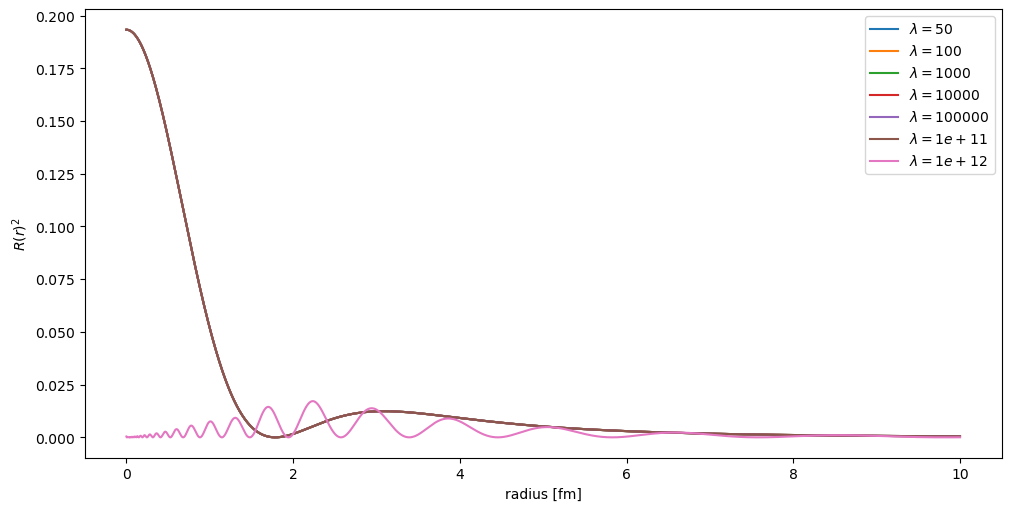

In [11]:
#plotting pseudopotential wavefunction
def pseudopotential_radial_wavefunction(x_values, wavefunction_eigenvector, orbital_quantum_number,
                                       sum_limit=SUM_LIMIT):
    def gaussian_wavefunction(radius, range_parameter, l):
        normalisation = (2**(-2.5-l) * range_parameter**(3+2*l) * gamma(1.5+l))**(-0.5)
        return normalisation * radius**l * np.exp(- (radius / range_parameter)**2)
    
    coeffs = np.asarray(wavefunction_eigenvector).ravel()
    wavefunction_vals = np.zeros(len(x_values))
    
    for i, r in enumerate(x_values):
        psi = 0.0
        for j in range(sum_limit):
            beta = next_range_parameter(j)
            psi += coeffs[j] * gaussian_wavefunction(r, beta, orbital_quantum_number)
        wavefunction_vals[i] = psi**2
        
    return wavefunction_vals

lambda_values_to_plot = [50, 100, 1000, 10000, 100000, 1E+11, 1E+12]
x_values = np.linspace(0, 10, 3000)

fig = plt.figure(figsize=(10,5), layout='constrained')
ax = fig.add_subplot(111)

for i in lambda_values_to_plot:
    pseudo_s_h_matrix, pseudo_s_n_matrix = pseudopotential_matrix_generation(0.5, 0, s0_eigenvector,
                                                                            0, lambda_param=i)
    pseudo_s_eigenvalues, pseudo_s_eigenvectors = scipy.linalg.eigh(pseudo_s_h_matrix, 
                                                                   pseudo_s_n_matrix)
    pseudo_ground_state = pseudo_s_eigenvectors[:, 0]
    
    wavefunction_values = pseudopotential_radial_wavefunction(x_values, pseudo_ground_state, 0)
    ax.plot(x_values, wavefunction_values, label=fr'$\lambda={i:g}$')
    
ax.set_xlabel('radius [fm]')
ax.set_ylabel(r'$R(r)^2$')
#ax.set_title('pseudopotential ground-state wavefunctions')
ax.legend()
plt.savefig('pseudopotential wavefunction.png')
plt.show()

As seen, the pseudopotential method begins to break down with an unphysical choice of $\lambda$ (i.e. $\lambda = 10^{12}$)